## 1. Import bibliotek

In [8]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

## 2. Połączenie z bazą danych

In [9]:
with open('db_config.json', 'r') as f:
    config = json.load(f)
    db_path = config['db_path']
    print("Ścieżka do bazy:", db_path)

conn = sqlite3.connect(db_path)
df = pd.read_sql_query("SELECT * FROM measurements", conn)
conn.close()

Ścieżka do bazy: ../data_collector/air_quality.db


## 3. Wstępny podgląd danych
**Wyświetlenie pierwszych oraz ostatnich 10 wierszy wczytanej tabeli, w celu sprawdzenia połączenia.**

In [10]:
df.head(10)

,id,timestamp,station_id,temperature,pressure,altidute,pm1_0,pm2_5,pm10_0
0,1,2026-05-16 10:51:22,station_01,22.09,948.985781,549.3323,3,5,5
1,2,2026-05-16 10:51:52,station_01,22.10,949.000391,549.2040,3,5,5
2,3,2026-05-16 10:52:23,station_01,22.11,949.026094,548.9781,4,6,6
3,4,2026-05-16 10:52:53,station_01,22.07,949.012500,549.0975,4,5,6
4,5,2026-05-16 10:53:23,station_01,21.99,949.087500,548.4390,3,5,6
5,6,2026-05-16 10:53:53,station_01,21.96,949.071875,548.5763,5,6,6
6,7,2026-05-16 10:54:23,station_01,21.93,949.112734,548.2179,5,6,6
7,8,2026-05-16 10:54:54,station_01,21.89,949.087813,548.4363,4,5,6
8,9,2026-05-16 10:55:24,station_01,21.85,949.126172,548.0997,4,5,5
9,10,2026-05-16 10:56:04,station_01,21.83,949.073125,548.5657,3,5,5


In [11]:
df.tail(10)

,id,timestamp,station_id,temperature,pressure,altidute,pm1_0,pm2_5,pm10_0
1061,1062,2026-05-16 19:41:55,station_01,22.65,953.128125,513.0295,4,6,6
1062,1063,2026-05-16 19:42:25,station_01,22.65,953.135000,512.9688,5,6,6
1063,1064,2026-05-16 19:42:55,station_01,22.67,953.151719,512.8229,5,6,6
1064,1065,2026-05-16 19:43:25,station_01,22.68,953.140781,512.9181,4,6,7
1065,1066,2026-05-16 19:43:55,station_01,22.68,953.139063,512.9339,4,5,5
1066,1067,2026-05-16 19:44:25,station_01,22.70,953.128047,513.0301,4,7,7
1067,1068,2026-05-16 19:44:55,station_01,22.69,953.144063,512.8901,4,7,7
1068,1069,2026-05-16 19:45:25,station_01,22.71,953.144500,512.8859,5,6,6
1069,1070,2026-05-16 19:45:55,station_01,22.72,953.183359,512.5461,5,7,7
1070,1071,2026-05-16 19:46:25,station_01,22.73,953.132500,512.9910,5,7,7


## 4. Sprawdzenie typów danych
**Upewnienie się czy wartości numeryczne (temperatura, pm1.0, itd.) zostały poprawnie zinterpretowane jako liczby, a nie jako tekst.**

In [12]:
df.dtypes

id               int64
timestamp          str
station_id         str
temperature    float64
pressure       float64
altidute       float64
pm1_0            int64
pm2_5            int64
pm10_0           int64
dtype: object

## 5. Konwersja czasu
**Znacznik czasu traktowany jest jako zwykły ciąg znaków, więc dokonuje konwersji kolumny `timestamp` na natywny typ obiektów daty i czasu (`datetime64`). Jest to kluczowe do prowadzenia analizy czasu.**

In [13]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [14]:
df.dtypes

id                      int64
timestamp      datetime64[us]
station_id                str
temperature           float64
pressure              float64
altidute              float64
pm1_0                   int64
pm2_5                   int64
pm10_0                  int64
dtype: object

## 6. Ustawienie indeksu tabeli
**Ustawiam kolumne czasu jako główny indeks DataFrame, ponieważ filtrowanie po datach oraz późniejsza praca z pomiarami będzie szybsza i bardziej intuicyjna.**

In [15]:
df = df.set_index('timestamp')

In [16]:
df.index.name

'timestamp'

In [17]:
df.index.dtype

dtype('<M8[us]')

**`M8[us]` to wewnętrzne, techniczne oznaczenie formatu datetime64[us] w bibliotece NumPy. Litera `M8` oznacza datę i czas, a [us] oznacza mikrosekundy.**

## 7. Usunięcie kolumny z id
**Kolumna 'id' jest nadmiarowa i postanawiam ją usunąć, aby nie zakłócać przyszłej analizy.**

In [18]:
df = df.drop('id', axis = 1)

In [19]:
df.dtypes

station_id         str
temperature    float64
pressure       float64
altidute       float64
pm1_0            int64
pm2_5            int64
pm10_0           int64
dtype: object

## 8. Sprawdzenie braków w danych
**Urządzenia IoT często bywają niestabilne z powodu z problemów z zasilaniem lub siecią WiFi. Dlatego sprawdzę czy w bazie występują puste komórki, a jak występują to w jakich kolumnach oraz ile ich jest.**

In [20]:
df.isnull().sum()

station_id     0
temperature    0
pressure       0
altidute       0
pm1_0          0
pm2_5          0
pm10_0         0
dtype: int64

In [21]:
df.index.isnull().sum()

np.int64(0)

**Jak widać nie ma braków danych, więc nie ma potrzeby ich uzupełniania. Gdyby taki problem wystąpił skorzystałbym z algorytmu interpolacji liniowej, który pozwala na matematyczne "wygładzenie" oraz uzupełnienie brakujących danych na podstawie wartości bezpośrednio poprzedzających lukę oraz następującej po niej.**

## 9. Statystyki opisowe
**Podsumowanie statystyczne całego zbioru danych:**

In [22]:
statystyki = df.describe().loc[['mean', 'min', 'max']]
statystyki.round(2)

,temperature,pressure,altidute,pm1_0,pm2_5,pm10_0
mean,21.60,951.32,528.86,5.17,6.84,7.16
min,20.66,948.99,512.55,1.00,2.00,2.00
max,22.83,953.18,549.33,8.00,11.00,14.00


**Interpretacja statystyk opisowych:**
* Liczebność zbioru (`count`) - 1071 pełnych i spójnych pomiarów dla każdego z parametrów.
* Temperatura (`temperature`) - Bardzo stabilna (średnia ~21.6°C, std = 0.56°C). Brak anomalii, warunki pokojowe.
* Ciśnienie i wysokość (`pressure`, `altidute`) - Wartości stabilne i poprawne fizycznie dla terenów wyżynnych (ciśnienie ~951 hPa, wysokość ~528 m n.p.m.).
* Czystość powietrza (`pm1_0`, `pm2_5`, `pm10_0`) - Bardzo niska koncentracja pyłów (mediana dla PM2.5 i PM10 wynosi 7.0 µg/m³). Powietrze jest bardzo czyste.
* Błędy pomiarowe - Brak wartości ujemnych, zerowych czy ekstremalnych maksimów, dane są czyste i poprawne.

## 10. Wykrywanie duplikatów

In [23]:
df.index.duplicated().sum()

np.int64(0)

**Przeprowadzona analiza wykazała 0 duplikatów, co potwierdza wysyłanie danych w stałym, zdefiniowanym odstępie czasowym.**

## 11. Wykres linii dla temperatury

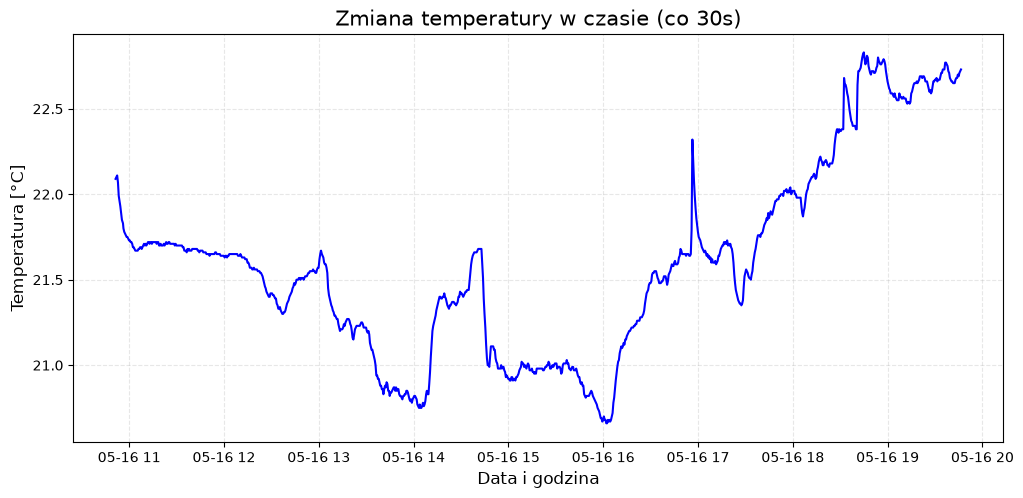

In [24]:
df['temperature'].plot(figsize = (12, 6), color = 'blue')

plt.title('Zmiana temperatury w czasie (co 30s)', fontsize = 15)
plt.xlabel('Data i godzina', fontsize = 12)
plt.xticks(rotation = 0, ha = 'center')
plt.ylabel('Temperatura [°C]', fontsize = 12)

plt.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

**Analiza przebiegu temperatury:**
1. **Anomalie i zdarzenia nagłe:**
   * Na wykresie wyraźnie widoczna jest pojedyncza anomalia w okolicach godziny 17:00, gdzie temperatura w bardzo krótkim czasie wzrosła o ok. 1°C, a następnie natychmiast spadła. Może to być spowodowane dotknięciem czujnika dłonią, dmuchnięciem ciepłym powietrzem lub po prostu chwilowym błędem oczytu danych.
2. **Gwałtowny wzrost temperatury w godzinach 17:00 - 19:00:**
   * W tych godzinach zaobserwowałem dynamiczny, liniowy wzrost temperatury z ok. 21.4°C do maksimum: 22.83°C. Taka zmiana w warunkach domowych zazwyczaj oznacza włączenie ogrzewania
3. **Wychładzanie:**
   * W pierwszej połowie dnia widoczny jest spadek temperatury, co sugeruje dopływy chłodniejszego powietrza do pomieszczenia. Szczególnie widać to w godzinach od 13:30 do 14:00 oraz 14:30 do 16:00 gdzie temperatura spada poniżej 21°C.

**Godzina i wartość wystąpienia najmniejszej temperatury:**

In [25]:
min_temp_val = df['temperature'].min()
min_temp_time = df['temperature'].idxmin()

f"Min: {min_temp_val}°C o godzinie: {min_temp_time}"

'Min: 20.66°C o godzinie: 2026-05-16 16:01:55'

**Godzina i wartosć wystąpienia największej temperatury:**

In [26]:
max_temp_val = df['temperature'].max()
max_temp_time = df['temperature'].idxmax()

f"Max: {max_temp_val}°C o godzinie: {max_temp_time}"

'Max: 22.83°C o godzinie: 2026-05-16 18:44:55'

## 12. Wykrycie i izolacja anomalii temperatury

**Na wykresie wyżej zaobserwowałem bardzo wyraźną anomalię tuż przed godzina 17:00, gdzie temperatura nagle wzrosła, a następnie zmalała. Wyświetle dane o tym czasie, w którym mogło to wystąpić:**

In [27]:
fragment_anomali = df.loc['2026-05-16 16:52:00':'2026-05-16 17:00:00']
fragment_anomali

,station_id,temperature,pressure,altidute,pm1_0,pm2_5,pm10_0
timestamp,,,,,,,
2026-05-16 16:52:25,station_01,21.64,952.059141,522.3852,6,7,7
2026-05-16 16:52:56,station_01,21.65,952.017500,522.7501,6,7,8
2026-05-16 16:53:25,station_01,21.65,952.006875,522.8431,6,7,7
2026-05-16 16:53:55,station_01,21.65,952.017500,522.7966,6,8,8
2026-05-16 16:54:25,station_01,21.64,952.034219,522.6036,5,7,7
2026-05-16 16:54:55,station_01,21.64,952.014688,522.7744,6,8,9
2026-05-16 16:55:25,station_01,21.65,952.022109,522.7099,5,7,8
2026-05-16 16:55:55,station_01,21.79,952.042656,522.5295,4,7,8
2026-05-16 16:56:25,station_01,22.32,951.962188,523.2345,6,9,9


In [28]:
fragment_anomali['skok_temp'] = fragment_anomali['temperature'].diff()
fragment_anomali

,station_id,temperature,pressure,altidute,pm1_0,pm2_5,pm10_0,skok_temp
timestamp,,,,,,,,
2026-05-16 16:52:25,station_01,21.64,952.059141,522.3852,6,7,7,NaN
2026-05-16 16:52:56,station_01,21.65,952.017500,522.7501,6,7,8,0.01
2026-05-16 16:53:25,station_01,21.65,952.006875,522.8431,6,7,7,0.00
2026-05-16 16:53:55,station_01,21.65,952.017500,522.7966,6,8,8,0.00
2026-05-16 16:54:25,station_01,21.64,952.034219,522.6036,5,7,7,-0.01
2026-05-16 16:54:55,station_01,21.64,952.014688,522.7744,6,8,9,0.00
2026-05-16 16:55:25,station_01,21.65,952.022109,522.7099,5,7,8,0.01
2026-05-16 16:55:55,station_01,21.79,952.042656,522.5295,4,7,8,0.14
2026-05-16 16:56:25,station_01,22.32,951.962188,523.2345,6,9,9,0.53


**Wnioski z analizy anomalii temperatury:**
1. **Lokalizacja anomalii:** Jak można zauważyć, że największy nagły skok temperatury miał dokładnie miejsce o godzinie 16:56:25 a różnica wynosiła aż 0.53°C.
2. **Możliwa przyczyna:** Najrozsądniejszym wytłumaczniem tego zjawiska będzie to, że ktoś podszedł do czujnika i w niego chuchnął.
3. **Wpływ na dane:** Zdarzenie to nie zaburza ogólnego, długoterminowego trendu, więc nie ma potrzeby usuwania tego wiersza, a jedynie odnotowania, że coś takiego wystąpiło.

## 13. Wykres linii dla ciśnienia

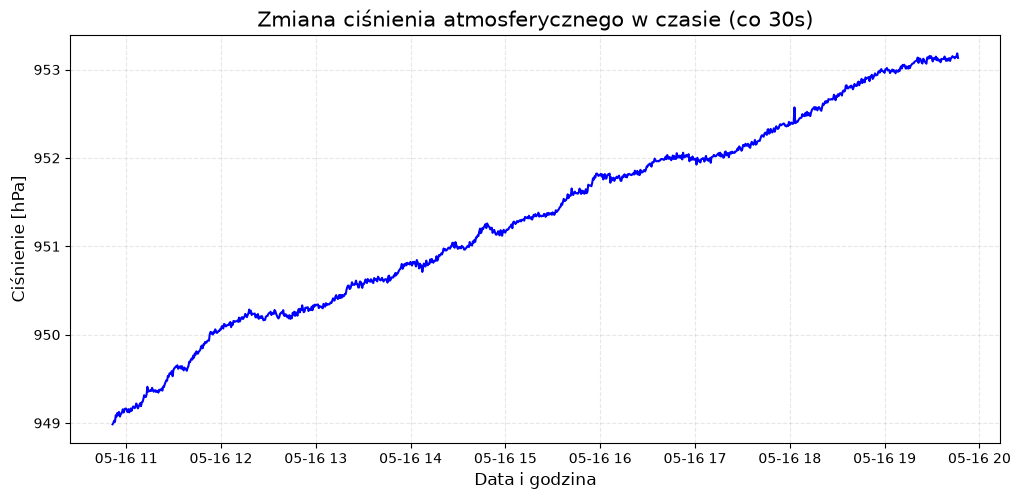

In [29]:
df['pressure'].plot(figsize = (12, 6), color = 'blue')

plt.title('Zmiana ciśnienia atmosferycznego w czasie (co 30s)', fontsize = 15)
plt.xlabel('Data i godzina', fontsize = 12)
plt.xticks(rotation = 0, ha = 'center')
plt.ylabel('Ciśnienie [hPa]', fontsize = 12)

plt.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

**Analiza przebiegu ciśnienia atmosferycznego:**
1. **Stabilny wzrost ciśnienia:**
   * Na wykresie wyraźnie widoczny jest jednostajny trend wzrostowy na przestrzeni całego dnia. Świadczy to o wkraczaniu w rejon pomiaru stabilnego układu wysokiego ciśnienia
2. **Brak wpływu mikroklimatu:**
   * W przeciwieństwie do temperatury, na tym wykresie nie widać żadnych wahań związanych z klimatem pomieszczenia, co potwierdza że ciśnienie w pomieszczeniach jest zawsze takie samo jak na zewnątrz.

**Godzina i wartość wystąpienia najmniejszego ciśnienia:**

In [30]:
min_press_val = df['pressure'].min()
min_press_time = df['pressure'].idxmin()

f"Min: {min_press_val} hPa o godzinie: {min_press_time}"

'Min: 948.9857812 hPa o godzinie: 2026-05-16 10:51:22'

**Godzina i wartość wystąpienia największego ciśnienia:**

In [31]:
max_press_val = df['pressure'].max()
max_press_time = df['pressure'].idxmax()

f"Max: {max_press_val} hPa o godzinie: {max_press_time}"

'Max: 953.1833594 hPa o godzinie: 2026-05-16 19:45:55'

## 14. Wygładzenie danych
**Przez to, że czujnik generuje drobne, losowe wahania (szum), nałoże na wykres temperatury i ciśnienia średnią kroczącą (rolling average). Pozwoli nam to ukryć te szumy aby pokazać gładki trend zmian.**

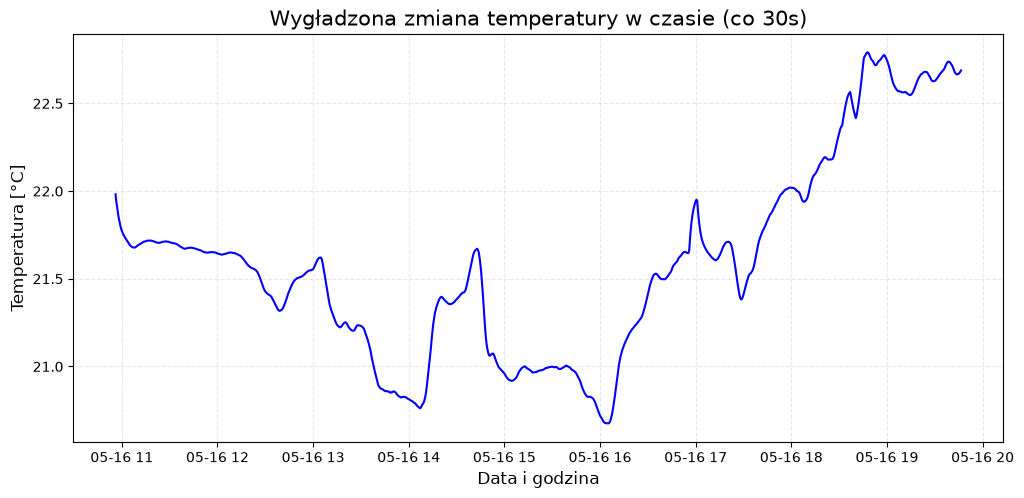

In [32]:
df['temp_rolling'] = df['temperature'].rolling(window = 10).mean()

df['temp_rolling'].plot(figsize = (12, 6), color = 'blue')

plt.title('Wygładzona zmiana temperatury w czasie (co 30s)', fontsize = 15)
plt.xlabel('Data i godzina', fontsize = 12)
plt.xticks(rotation = 0, ha = 'center')
plt.ylabel('Temperatura [°C]', fontsize = 12)

plt.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

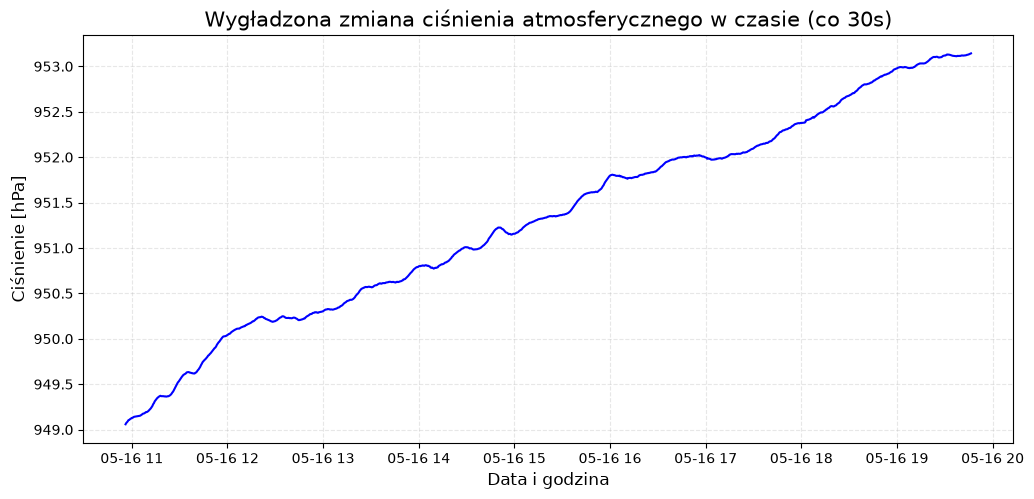

In [33]:
df['press_rolling'] = df['pressure'].rolling(window = 10).mean()

df['press_rolling'].plot(figsize = (12, 6), color = 'blue')

plt.title('Wygładzona zmiana ciśnienia atmosferycznego w czasie (co 30s)', fontsize = 15)
plt.xlabel('Data i godzina', fontsize = 12)
plt.xticks(rotation = 0, ha = 'center')
plt.ylabel('Ciśnienie [hPa]', fontsize = 12)

plt.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

**Wnioski z wygładzonych danych**
1. Zastosowanie `window = 10` przyniosło oczekiwany rezultat. Linie zostały wygładzone i wahania o amplitudzie ułamków, które były widoczne zostały wyeliminowane.
2. Wcześniej zaobserwowana anomalia temperatury koło godziny 17:00 została rozmyta w czasie, przez to jeszcze bardziej widać że nastała nagła zmiana warunków w pomieszczeniu

## 15. Tempo zmiany temperatury

**Obliczam pochodną zmian temperatury (tempo wzrostu / jednostka czasu):**

In [34]:
delta_temp = df['temperature'].diff()

delta_time_min = df.index.to_series().diff().dt.total_seconds() / 60

df['tempo_zmiany'] = delta_temp / delta_time_min

**Przyjmuje, że skok tempertury o 1°C na minute to zdarzenie termiczne:**

In [35]:
PROG_ALERTU = 1

okno_otwarte = df[df['tempo_zmiany'] < -PROG_ALERTU]

ogrzewanie_wlaczone = df[df['tempo_zmiany'] > PROG_ALERTU]

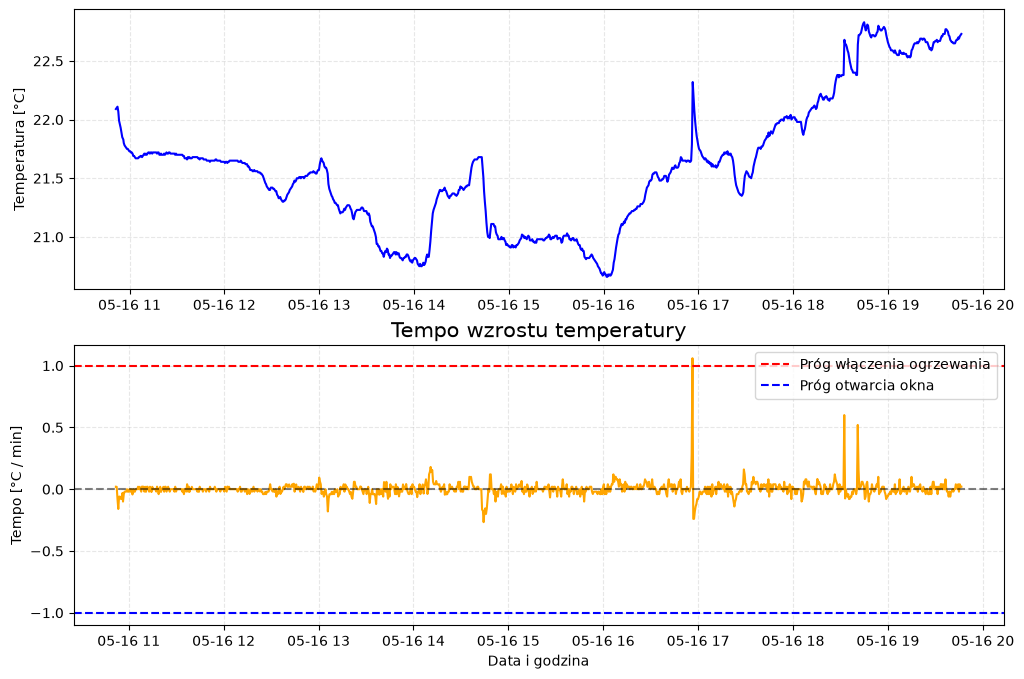

In [36]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Górny wykres
ax1.plot(df.index, df['temperature'], color = 'blue')
ax1.set_ylabel('Temperatura [°C]')
ax1.grid(True, linestyle = '--', alpha = 0.3)

# Dolny wykres
ax2.plot(df.index, df['tempo_zmiany'], color = 'orange')
ax2.set_title('Tempo wzrostu temperatury', fontsize = 15)
ax2.set_ylabel('Tempo [°C / min]')
ax2.set_xlabel('Data i godzina')
ax2.grid(True, linestyle = '--', alpha = 0.3)

ax2.axhline(0, color = 'black', linestyle = '--', alpha = 0.5) 
ax2.axhline(PROG_ALERTU, color = 'red', linestyle = '--', label = 'Próg włączenia ogrzewania')
ax2.axhline(-PROG_ALERTU, color = 'blue', linestyle = '--', label = 'Próg otwarcia okna')

ax2.legend()

plt.show()

**Wnioski dotyczące analizy progu zmiany temperatury:**
1. Dolny wykres pokazuje, że anomalia nagłego wzrostu temperatory koło godziny 17:00 była zdarzeniem gwałtownym. Tempo zmiany przekroczyło ustalony prób ostrzegawczy, osiągając wartość szczytową.
2. Między godziną 18:30 a 19:00 pojawiły się dwa wyraźne impulsy przyśpieszenia termincznego. 
3. Żaden z zarejestrowanych spadków temperatury nie zbliżył się do dolnego progu. Oznacza to, że pomieszczenie wychładzało się powolnie.
4. Przez większość dnia tempo zmian utrzymuje się wokół 0.0°C/min. Potwierdza to, że nie występują chaotyczne zmiany temperatury.

## 16. Wykres gęstośći (KDE) temperatury
**Tworze wykres estymacji gęstości jądorwej (KDE), który obrazuje jaka temperatura pojawiła się najczęściej:**

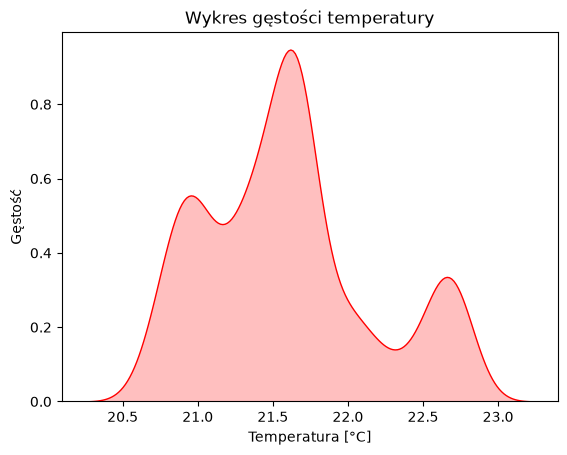

In [37]:
sns.kdeplot(df['temperature'], fill = True, color = 'red')

plt.xlabel('Temperatura [°C]')
plt.ylabel('Gęstość')
plt.title('Wykres gęstości temperatury')

plt.show()

**Wnioski dotyczące wykresu gęstościtemperatury:**
Wykres estymacji gęstości jądrowej (KDE) ujawnia, że rozkład temperatury jest rozkładem trimodalnym (posiadający trzy lokalne maksima/szczyty). Oznacza to, że analizowane środowisko przebywało w trzech różnych, dominujących stanach termicznych:
1. **Główny punkt pracy (Szczyt dominujący ok. 21.6°C):**
   * Najwyższy peak przypada dokładnie na okolice 21.6°C. Potwierdza to nasze wcześniejsze wyliczenia z tabeli statystyk opisowych (gdzie mediana wynosiła 21.58°C). Przez zdecydowaną większość czasu w pomieszczeniu panowała stabilna, kontrolowana temperatura bazowa.
2. **Stan wychłodzenia (Lewy szczyt ok. 20.9°C):**
   * Drugi, wyraźny szczyt rozkładu formuje się w okolicach 20.9°C. Reprezentuje on czas, w którym pomieszczenie podlegało regularnemu schładzaniu (co obserwowaliśmy na wykresie liniowym np. między godzinami 13:00 a 16:00). Obecność tak wyraźnego szczytu dowodzi, że stan obniżonej temperatury nie był chwilowym wahaniem, lecz trwałym procesem w ciągu dnia.
3. **Stan nagrzewania (Prawy szczyt ok. 22.6°C):**
   * Trzeci, najmniejszy szczyt pojawia się w rejonie wyższych temperatur, około 22.6°C - 22.7°C. Potwierdza on, że system grzewczy podniósł temperaturę otoczenia do wartości maksymalnych.

## 17. Wpływ ciśnienia na wysokość

**Obliczam korelacje między wysokością a ciśnieniem:**

In [38]:
korelacja = df['pressure'].corr(df['altidute'])
korelacja

np.float64(-0.9999969984830761)

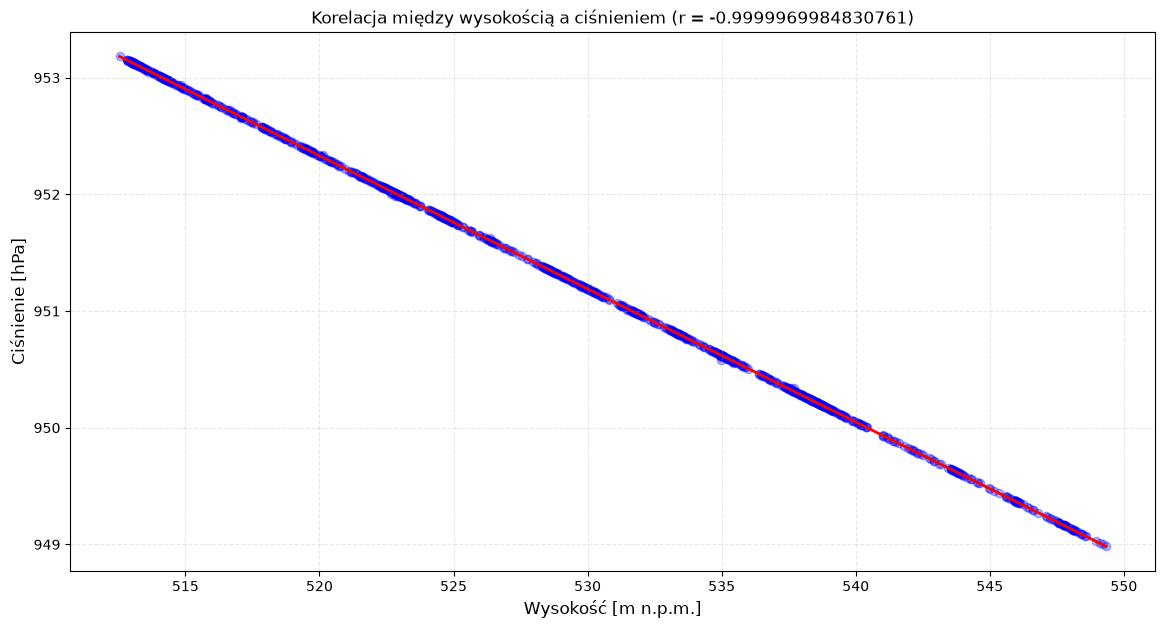

In [39]:
plt.figure(figsize = (14, 7))

sns.regplot(data = df, x = 'altidute', y = 'pressure', scatter_kws = {'alpha':0.3, 'color':'blue'}, 
            line_kws={'color':'red', 'linewidth':2})

plt.title(f'Korelacja między wysokością a ciśnieniem (r = {korelacja})', fontsize = 12)
plt.xlabel('Wysokość [m n.p.m.]', fontsize = 12)
plt.ylabel('Ciśnienie [hPa]', fontsize = 12)
plt.grid(True, linestyle='--', alpha = 0.3)

**Interpretacja współczynnika korelacji i wnioski:**
* **Perfekcyjna korelacja ujemna (r $\approx$ -1.0):**
  * Wynik wyliczony przez funkcję `.corr()` oraz wykres regresji z pliku wskazują na niemal idealną liniową korelację ujemną. Oznacza to, że każdy wzrost ciśnienia atmosferycznego skutkuje natychmiastowym, proporcjonalnym spadkiem wyliczanej wysokości nad poziomem morza.
* **Fizyczne wyjaśnienie zjawiska:**
  * Ten bezbłędny matematycznie kształt nie wynika z faktu, że mikrokontroler ESP32 fizycznie poruszał się w pionie. Wartość kolumny `altidute` jest przez kalkulowana na podstawie tzw. wzoru barometrycznego, przy założeniu stałego ciśnienia odniesienia na poziomie morza (1013.25 hPa). Wkraczający w ciągu dnia front wyżowy oszukał algorytm czujnika, sprawiając iż znajduje się coraz niżej.

## 18. Wykres liniowy dla pyłów zawieszonych (PM1.0, PM2.5, PM10)

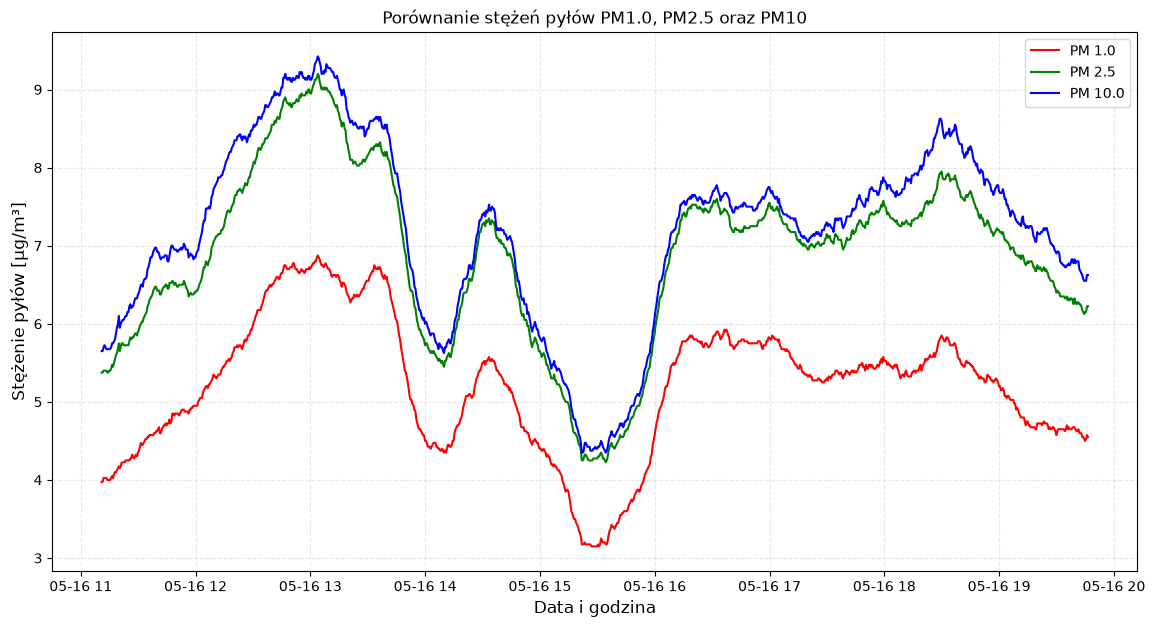

In [40]:
pm1_0 = df['pm1_0'].rolling(window = 40).mean()
pm2_5 = df['pm2_5'].rolling(window = 40).mean()
pm10 = df['pm10_0'].rolling(window = 40).mean()

plt.figure(figsize=(14, 7))

plt.plot(df.index, pm1_0, color = 'red', label = 'PM 1.0')
plt.plot(df.index, pm2_5, color = 'green',label = 'PM 2.5')
plt.plot(df.index, pm10, color = 'blue', label = 'PM 10.0')

plt.title('Porównanie stężeń pyłów PM1.0, PM2.5 oraz PM10', fontsize = 12)
plt.xlabel('Data i godzina', fontsize = 12)
plt.ylabel('Stężenie pyłów [µg/m³]', fontsize = 12)

plt.grid(True, linestyle = '--', alpha = 0.3)
plt.legend(fontsize = 10, loc = 'upper right')

plt.show()

**Wartość maksymalna PM 1.0:**

In [41]:
pm1_0.max()

np.float64(6.875)

**Wartość maksymalna PM 2.5:**

In [42]:
pm2_5.max()

np.float64(9.2)

**Wartość maksymalna PM 10.0:**

In [43]:
pm10.max()

np.float64(9.425)

**Obliczenie różnicy względem maksymalnych wartości z całego zbioru danych:**

In [44]:
diff_pm1_0 = df.pm1_0.max() - pm1_0.max() 
diff_pm2_5 = df.pm2_5.max() - pm2_5.max()
diff_pm10_0 = df.pm10_0.max() - pm10.max()

In [45]:
print(f'Wartość maksymalna PM 1.0 zmalała o {round(diff_pm1_0, 3)}')
print(f'Wartość maksymalna PM 2.5 zmalała o {round(diff_pm2_5, 3)}')
print(f'Wartość maksymalna PM 10.0 zmalała o {round(diff_pm10_0, 3)}')

Wartość maksymalna PM 1.0 zmalała o 1.125
Wartość maksymalna PM 2.5 zmalała o 1.8
Wartość maksymalna PM 10.0 zmalała o 4.575


**Wnioski z analizy stężeń pyłów zawieszonych (PM1.0, PM2.5, PM10.0):**
* **Konieczność filtracji sygnału (Parametr window = 40):**
  * Surowe dane z optycznego czujnika pyłów charakteryzowały się bardzo wysoką częstotliwością zmian i ogromnym szumem pomiarowym (ciągłe, chaotyczne skoki wartości wywołane m.in. pojedynczymi drobinami kurzu przelatującymi przez komorę pomiarową). Aby wydobyć realne trendy, zastosowałem średnią kroczącą o szerokim oknie `window=40` (uśrednianie z 20 minut). Dopiero tak agresywna filtracja pozwoliła na uzyskanie płynnych, czytelnych krzywych i eliminację szumu bez utraty globalnego charakteru zmian.
* **Ogólna ocena jakości powietrza:**
  * W całym badanym okresie jakość powietrza w otoczeniu stacji była doskonała. Maksymalne wygładzone stężenia dla najgroźniejszej frakcji PM2.5 oraz PM10.0 nie przekroczyły nawet 9.5 $\mu g/m^3$.
* **Struktura i korelacja frakcji pyłów:**
  * Na wykresie widoczna jest uderzająca zależność: linie dla **PM2.5 (zielona)** oraz **PM10.0 (niebieska)** niemal w całości pokrywają się lub biegną skrajnie blisko siebie. Minimalna różnica między nimi oznacza, że w powietrzu praktycznie nie było pyłów grubych (kurzu, pyłu zawieszonego). Z kolei linia **PM1.0 (czerwona)** idealnie odwzorowuje kształt pozostałych dwóch linii, utrzymując się stale o około 2 $\mu g/m^3$ niżej. Świadczy to o tym, że wszystkie trzy frakcje pochodziły dokładnie z tego samego źródła zanieczyszczeń.
* **Analiza przebiegu czasowego i dynamiki (Piki i doliny):**
  * **Wzrost (Godz. 12:00 - 13:00):** Obserwujemy wyraźny, popołudniowy wzrost stężeń, co może wiązać się ze zwiększonym ruchem w pomieszczeniu, który wzbił osiadłe cząstki w powietrze.
  * **Gwałtowny spadek (Godz. 13:30 - 14:15):** Widoczny na wykresie nagły spadek poziomu pyłów o ponad połowę (spadek PM10.0 z ok. 9.5 do 5.5 $\mu g/m^3$) idealnie pokrywa się w czasie z zaobserwowanym wcześniej spadkiem temperatury. To dowód na to, że w tych godzinach pomieszczenie było intensywnie wietrzone. 
  * **Drugi szczyt (Okolicach godz. 18:30):** Ponowny wzrost zanieczyszczeń zbiega się z wieczornym powrotem temperatury do wartości maksymalnych, co potwierdza ponowne zamknięcie okien i gromadzenie się cząstek w zamkniętej przestrzeni.

## 19. Wskaźnik proporcji PM2.5 do PM10
**Wysoka wartość tego wskaźnika sugeruje zanieczyszczenia z procesów spalania (np. smog), niska to np. pyły mechaniczne (kurz).**

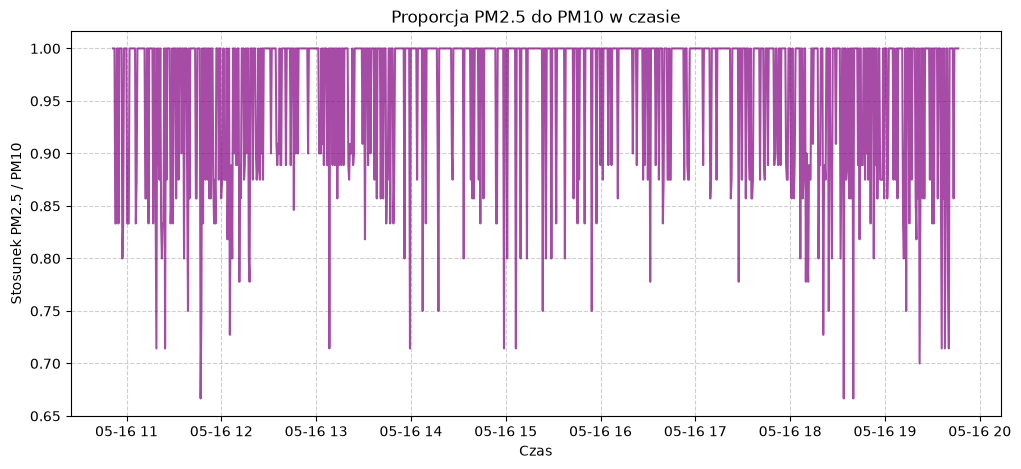

Średni stosunek PM2.5 do PM10: 0.96


In [46]:
# Obliczenie stosunku PM2.5 do PM10
df['pm2_5_to_pm10_ratio'] = df['pm2_5'] / df['pm10_0']

# Wizualizacja
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['pm2_5_to_pm10_ratio'], color='purple', alpha=0.7)
plt.title('Proporcja PM2.5 do PM10 w czasie')
plt.ylabel('Stosunek PM2.5 / PM10')
plt.xlabel('Czas')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Średnia wartość wskaźnika
print(f"Średni stosunek PM2.5 do PM10: {df['pm2_5_to_pm10_ratio'].mean():.2f}")


## 20. Weryfikacja przekroczeń norm jakości powietrza (WHO)
**Normy WHO (dobowe): PM2.5 - 15 µg/m³, PM10 - 45 µg/m³.**

In [47]:
# Flagi przekroczeń norm WHO
df['pm2_5_exceeds_who'] = df['pm2_5'] > 15
df['pm10_0_exceeds_who'] = df['pm10_0'] > 45

# Podsumowanie
exceed_pm25 = df['pm2_5_exceeds_who'].sum()
exceed_pm10 = df['pm10_0_exceeds_who'].sum()
total_records = len(df)

print(f"Przekroczenia normy PM2.5: {exceed_pm25} z {total_records} pomiarów ({(exceed_pm25/total_records)*100:.1f}%)")
print(f"Przekroczenia normy PM10: {exceed_pm10} z {total_records} pomiarów ({(exceed_pm10/total_records)*100:.1f}%)")


Przekroczenia normy PM2.5: 0 z 1071 pomiarów (0.0%)
Przekroczenia normy PM10: 0 z 1071 pomiarów (0.0%)


## 21. Histogram stężeń PM2.5
**Rozkład częstości występowania poszczególnych stężeń pyłu PM2.5.**

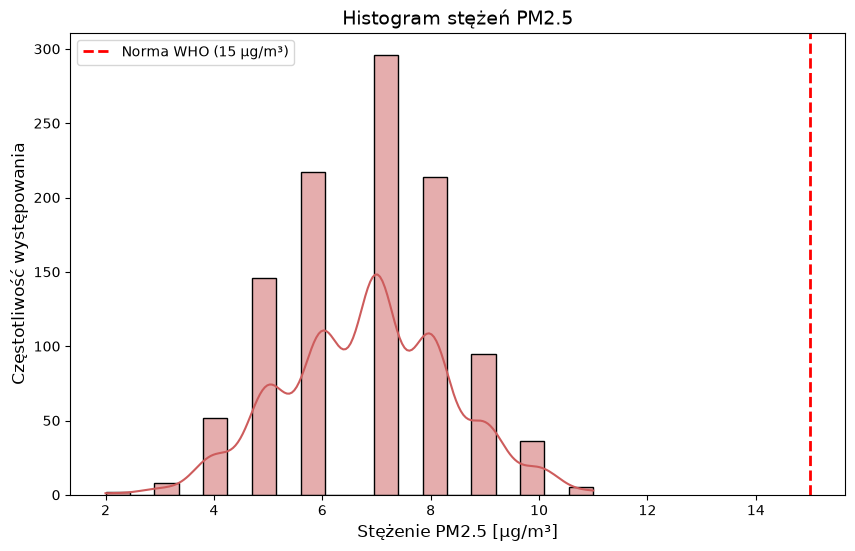

In [48]:
plt.figure(figsize=(10, 6))
sns.histplot(df['pm2_5'], bins=20, kde=True, color='indianred')
plt.title('Histogram stężeń PM2.5', fontsize=14)
plt.xlabel('Stężenie PM2.5 [µg/m³]', fontsize=12)
plt.ylabel('Częstotliwość występowania', fontsize=12)
plt.axvline(15, color='red', linestyle='dashed', linewidth=2, label='Norma WHO (15 µg/m³)')
plt.legend()
plt.show()


## 22. Macierz korelacji i Heatmapa
**Badanie matematycznych zależności między zmiennymi (temperatura, ciśnienie, pyły).**

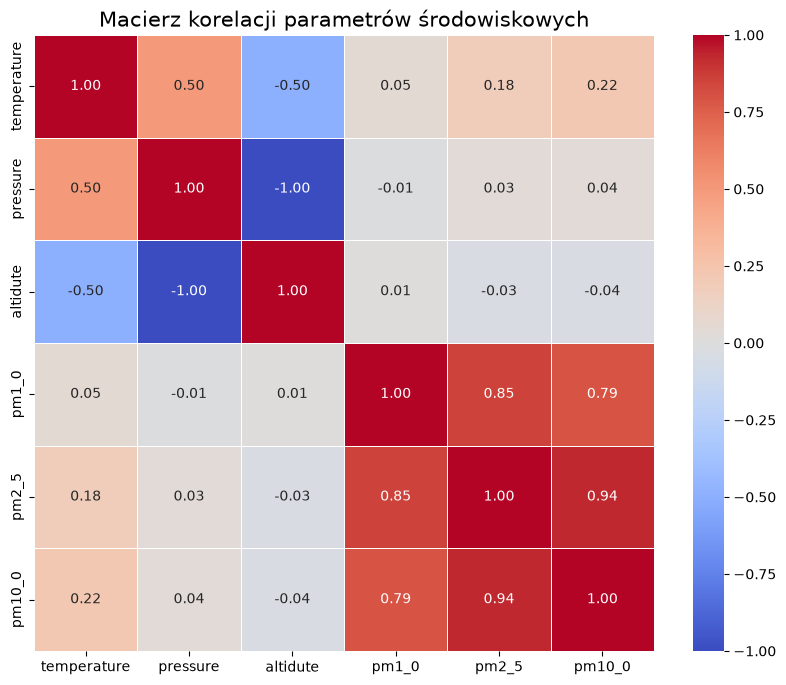

In [49]:
# Obliczenie macierzy korelacji Pearsona (wykluczając kolumny nienumeryczne)
cols_to_corr = ['temperature', 'pressure', 'altidute', 'pm1_0', 'pm2_5', 'pm10_0']
corr_matrix = df[cols_to_corr].corr()

# Rysowanie heatmapy
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
plt.title('Macierz korelacji parametrów środowiskowych', fontsize=15)
plt.show()


## 23. Wielowymiarowy wykres relacji (Pairplot)
**Wizualizacja wszystkich relacji dwuzmiennych w jednym widoku.**

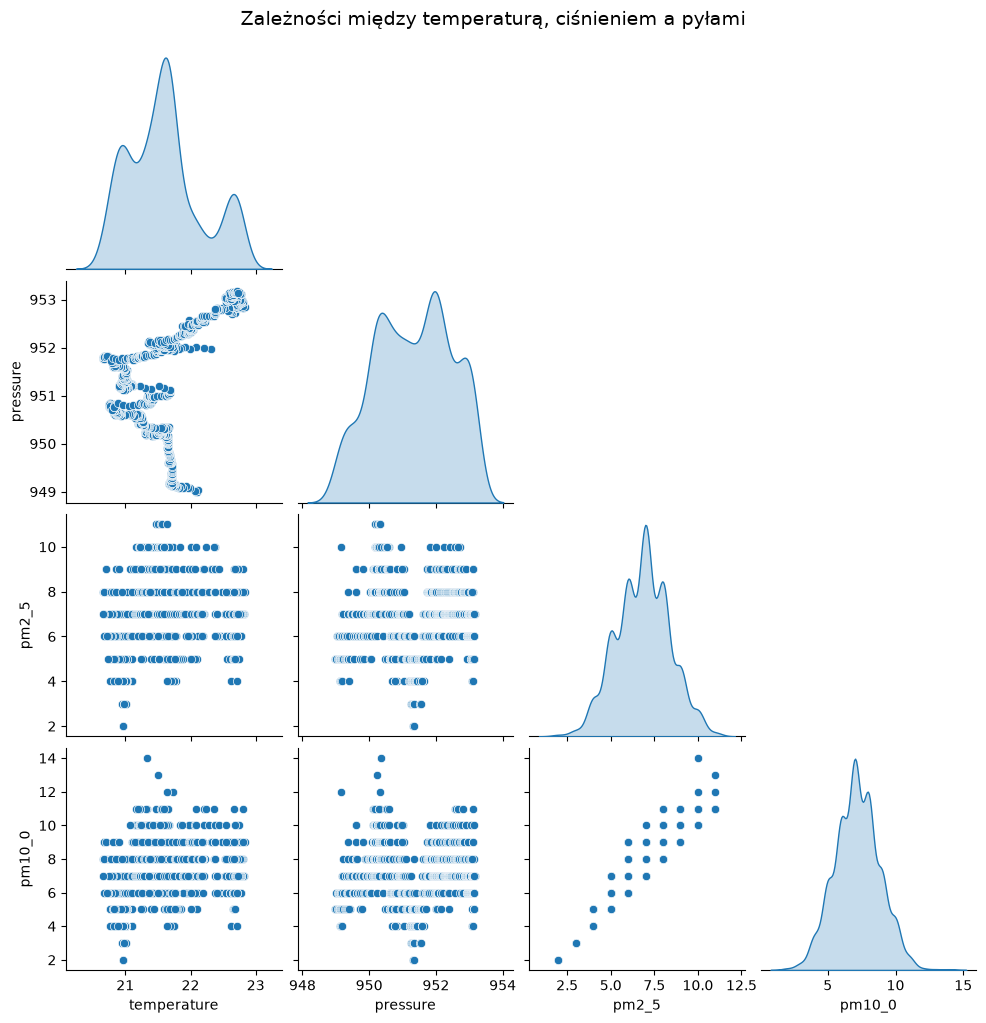

In [50]:
# Wybieramy tylko podstawowe parametry
sns.pairplot(df[['temperature', 'pressure', 'pm2_5', 'pm10_0']], diag_kind='kde', corner=True)
plt.suptitle('Zależności między temperaturą, ciśnieniem a pyłami', y=1.02, fontsize=14)
plt.show()


## 24. Dobowy profil godzinowy (Hourly Profile)
**Typowy rozkład stężeń w zależności od godziny w ciągu doby.**

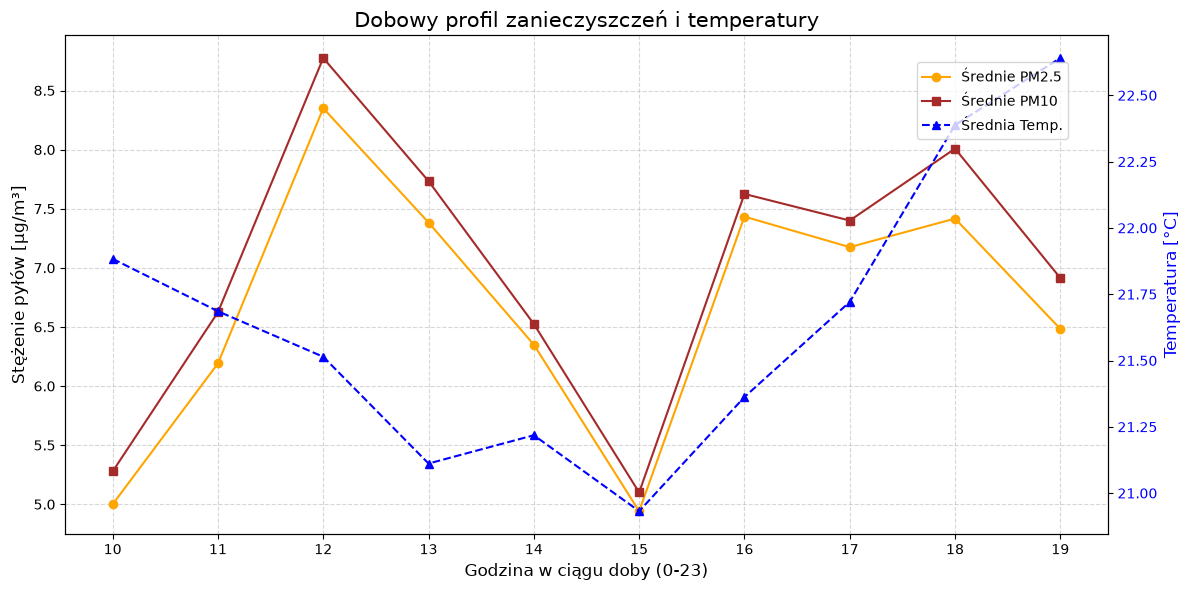

In [51]:
# Tworzenie kolumny z godziną
df['hour'] = df.index.hour

# Agregacja do średnich wartości w poszczególnych godzinach
hourly_profile = df.groupby('hour')[['pm2_5', 'pm10_0', 'temperature']].mean()

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.set_xlabel('Godzina w ciągu doby (0-23)', fontsize=12)
ax1.set_ylabel('Stężenie pyłów [µg/m³]', fontsize=12)
ax1.plot(hourly_profile.index, hourly_profile['pm2_5'], marker='o', label='Średnie PM2.5', color='orange')
ax1.plot(hourly_profile.index, hourly_profile['pm10_0'], marker='s', label='Średnie PM10', color='brown')
ax1.tick_params(axis='y')
ax1.set_xticks(range(0, 24))
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = ax1.twinx()  
ax2.set_ylabel('Temperatura [°C]', color='blue', fontsize=12)  
ax2.plot(hourly_profile.index, hourly_profile['temperature'], marker='^', linestyle='dashed', color='blue', label='Średnia Temp.')
ax2.tick_params(axis='y', labelcolor='blue')

fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.9))
plt.title('Dobowy profil zanieczyszczeń i temperatury', fontsize=15)
fig.tight_layout()  
plt.show()


## 25. Kalkulator indeksu jakości powietrza (AQI)
**Wyznaczanie klas jakości powietrza na podstawie stężenia PM2.5.**

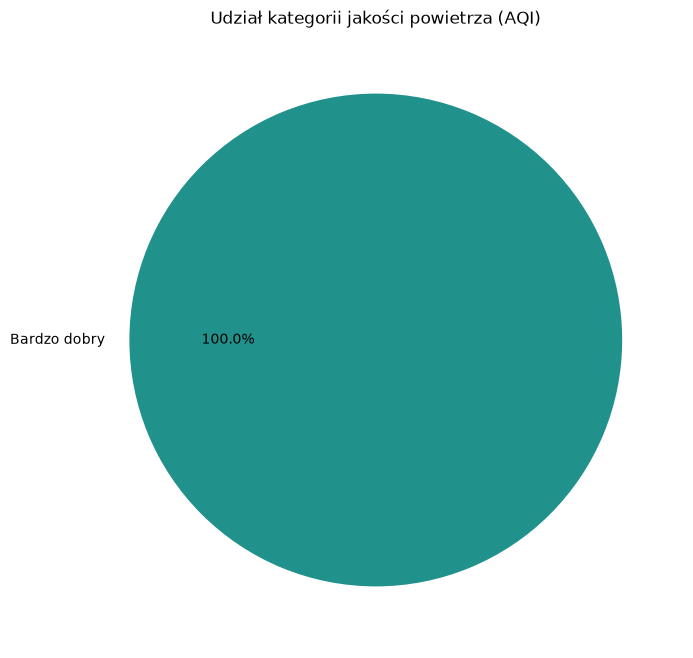

In [52]:
def get_aqi_category(pm25):
    if pm25 <= 13:
        return 'Bardzo dobry'
    elif pm25 <= 35:
        return 'Dobry'
    elif pm25 <= 55:
        return 'Umiarkowany'
    elif pm25 <= 75:
        return 'Dostateczny'
    elif pm25 <= 110:
        return 'Zły'
    else:
        return 'Bardzo zły'

df['AQI_Category'] = df['pm2_5'].apply(get_aqi_category)

# Zliczenie wystąpień kategorii
aqi_counts = df['AQI_Category'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(aqi_counts, labels=aqi_counts.index, autopct='%1.1f%%', colors=sns.color_palette('viridis', len(aqi_counts)))
plt.title('Udział kategorii jakości powietrza (AQI)')
plt.show()


## 26. Eksport oczyszczonego zbioru do pliku CSV
**Zapisujemy wynik naszej analizy do pliku gotowego dla ewentualnych modeli ML.**

In [53]:
clean_data_path = 'air_quality_clean.csv'
df.to_csv(clean_data_path)
print(f"Dane pomyślnie zapisane do: {clean_data_path}")


Dane pomyślnie zapisane do: air_quality_clean.csv
